# ML-04 — Search Intelligence Data Contract

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/asad-raza-929/Flyrank_Internship_ml/blob/main/work/notebooks/w03_data_contract.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

This notebook aims to define a data contract for a search intelligence dataset. As no specific data source was provided, I will generate a synthetic dataset to illustrate the concepts for each section. In a real-world scenario, you would replace the data generation step with actual data loading from your defined 'skill' as hinted in the first cell.

In [15]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic data for a search intelligence context
num_records = 10000
dates = pd.to_datetime(pd.date_range(start='2023-01-01', periods=30, freq='D').to_numpy().reshape(-1, 1).repeat(num_records // 30, axis=0).flatten()[:num_records])

# Ensure all dates are within the initial 30 day range by adjusting total records slightly
if len(dates) < num_records:
    dates = np.concatenate([dates, pd.to_datetime(pd.date_range(start='2023-01-01', periods=30, freq='D'))[np.random.randint(0, 30, num_records - len(dates))]])

data = {
    'date': dates,
    'user_id': np.random.randint(1000, 5000, num_records),
    'query': np.random.choice(['buy shoes', 'best laptop', 'how to cook', 'travel deals', 'weather today', 'news headlines'], num_records),
    'device': np.random.choice(['mobile', 'desktop', 'tablet'], num_records, p=[0.6, 0.3, 0.1]),
    'country': np.random.choice(['USA', 'CAN', 'GBR', 'DEU'], num_records, p=[0.5, 0.2, 0.15, 0.15]),
    'impressions': np.random.randint(1, 20, num_records),
    'clicks': np.random.randint(0, 5, num_records),
    'is_organic_click': np.random.choice([0, 1], num_records, p=[0.7, 0.3]) # 0 for non-organic, 1 for organic
}

df = pd.DataFrame(data)

# Ensure clicks are less than or equal to impressions
df['clicks'] = df.apply(lambda row: min(row['clicks'], row['impressions']), axis=1)

df.sort_values(by='date', inplace=True)

print("Synthetic DataFrame created with the following head:")
display(df.head())
print("\nDataFrame Info:")
df.info()


Synthetic DataFrame created with the following head:


,date,user_id,query,device,country,impressions,clicks,is_organic_click
0,2023-01-01,1466,buy shoes,mobile,USA,11,3,0
226,2023-01-01,2529,weather today,mobile,USA,19,0,1
225,2023-01-01,2663,travel deals,desktop,USA,18,3,0
224,2023-01-01,2354,buy shoes,mobile,CAN,4,2,0
223,2023-01-01,2981,travel deals,mobile,GBR,4,0,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9747
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              10000 non-null  datetime64[ns]
 1   user_id           10000 non-null  int64         
 2   query             10000 non-null  object        
 3   device            10000 non-null  object        
 4   country           10000 non-null  object        
 5   impressions       10000 non-null  int64         
 6   clicks            10000 non-null  int64         
 7   is_organic_click  10000 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 703.1+ KB


## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

For this search intelligence dataset, the **unit of analysis** is a unique combination of `(date, user_id, query, device, country)`. Each row represents a summary of search events for a specific user, on a specific device, from a specific country, for a particular query on a given day. The **time window** covered by this data is from `2023-01-01` to `2023-01-30`.

This granularity allows us to analyze daily user behavior patterns for specific search queries across different devices and geographies.

In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [17]:
# Verify the unit of analysis by checking for duplicates based on the defined grain
unit_of_analysis_cols = ['date', 'user_id', 'query', 'device', 'country']
duplicate_rows = df.duplicated(subset=unit_of_analysis_cols).sum()
print(f"Number of duplicate rows based on the unit of analysis ({', '.join(unit_of_analysis_cols)}): {duplicate_rows}")

# If duplicates exist, it means our definition of the unit of analysis might need refinement or aggregation.
# For this synthetic data, we expect few or no exact duplicates after initial generation.

# Verify the time window
min_date = df['date'].min()
max_date = df['date'].max()
print(f"Data covers the period from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")

# Display the number of unique units of analysis
unique_units = df.drop_duplicates(subset=unit_of_analysis_cols).shape[0]
print(f"Number of unique units of analysis: {unique_units}")
print(f"Total rows in the dataset: {len(df)}")

Number of duplicate rows based on the unit of analysis (date, user_id, query, device, country): 9
Data covers the period from 2023-01-01 to 2023-01-30
Number of unique units of analysis: 9991
Total rows in the dataset: 10000


## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

Here's how the fields in our synthetic search intelligence dataset are categorized:

*   **Features:** These are the input variables used to make predictions.
    *   `query`: The search term entered by the user.
    *   `device`: The type of device used for the search (e.g., 'mobile', 'desktop').
    *   `country`: The geographical location from where the search originated.
    *   `impressions`: The number of times a search result appeared to the user for the given query.

*   **Label:** This is the target variable we aim to predict.
    *   `clicks`: The number of times a user clicked on a search result for the given query.
    *   (`is_organic_click` could also be a label for binary classification, but for this example, we focus on `clicks` as a continuous target).

*   **Context:** These fields provide additional information but are not directly used as features or labels for the primary prediction task. They are useful for filtering, grouping, or understanding the data.
    *   `date`: The day the search event occurred.
    *   `user_id`: A unique identifier for the user.

*   **Excluded:** These fields are not used in the analysis.
    *   `internal_id` (hypothetical): A unique internal system ID that might be present in a real dataset. **Reason for exclusion:** It's an internal identifier with no predictive power and can introduce bias if used improperly. (Not present in synthetic data, but used for demonstration of exclusion rationale).

In [18]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [19]:
# Display the first few rows to confirm field presence and data types
display(df.head())

# Display the data types and non-null counts for each field
print("\nDataFrame Information (dtypes and non-null counts):")
df.info()

# Display descriptive statistics for numerical fields
print("\nDescriptive Statistics for Numerical Fields:")
display(df.describe())

,date,user_id,query,device,country,impressions,clicks,is_organic_click
0,2023-01-01,1466,buy shoes,mobile,USA,11,3,0
226,2023-01-01,2529,weather today,mobile,USA,19,0,1
225,2023-01-01,2663,travel deals,desktop,USA,18,3,0
224,2023-01-01,2354,buy shoes,mobile,CAN,4,2,0
223,2023-01-01,2981,travel deals,mobile,GBR,4,0,0



DataFrame Information (dtypes and non-null counts):
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9747
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              10000 non-null  datetime64[ns]
 1   user_id           10000 non-null  int64         
 2   query             10000 non-null  object        
 3   device            10000 non-null  object        
 4   country           10000 non-null  object        
 5   impressions       10000 non-null  int64         
 6   clicks            10000 non-null  int64         
 7   is_organic_click  10000 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 703.1+ KB

Descriptive Statistics for Numerical Fields:


,date,user_id,impressions,clicks,is_organic_click
count,10000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2023-01-15 12:02:35.520000,3010.269900,9.916500,1.893300,0.309200
min,2023-01-01 00:00:00,1000.000000,1.000000,0.000000,0.000000
25%,2023-01-08 00:00:00,2001.000000,5.000000,1.000000,0.000000
50%,2023-01-15 12:00:00,3003.500000,10.000000,2.000000,0.000000
75%,2023-01-23 00:00:00,4010.000000,15.000000,3.000000,1.000000
max,2023-01-30 00:00:00,4999.000000,19.000000,4.000000,1.000000
std,NaN,1152.298913,5.468576,1.374156,0.462187


## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

This section verifies several claims about the dataset using explicit queries:

1.  **Grain Verification:** Confirm that each row adheres to the defined unit of analysis (daily (user, query, device, country) search event), meaning there are no duplicate entries for this combination.
2.  **Total Record Count:** Report the total number of records in the dataset.
3.  **Missing Values:** Identify and quantify any missing values for each field.
4.  **Date Window Integrity:** Confirm the minimum and maximum dates within the dataset match the expected time window.
5.  **Categorical Feature Distribution:** Check the distribution of unique values for categorical features to understand their cardinality.

In [20]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [21]:
# 1. Grain Verification: Re-check for duplicates based on the unit of analysis
unit_of_analysis_cols = ['date', 'user_id', 'query', 'device', 'country']
duplicate_check = df.duplicated(subset=unit_of_analysis_cols).sum()
print(f"Verification 1 (Grain): Number of duplicate rows for the defined unit of analysis: {duplicate_check}")

# 2. Total Record Count
total_records = len(df)
print(f"Verification 2 (Total Records): Total number of records in the dataset: {total_records}")

# 3. Missing Values
missing_values = df.isnull().sum()
print("\nVerification 3 (Missing Values): Count of missing values per column:")
print(missing_values)

# 4. Date Window Integrity
min_date_actual = df['date'].min()
max_date_actual = df['date'].max()
expected_min_date = pd.to_datetime('2023-01-01')
expected_max_date = pd.to_datetime('2023-01-30')
print(f"\nVerification 4 (Date Window): Actual date range: {min_date_actual.strftime('%Y-%m-%d')} to {max_date_actual.strftime('%Y-%m-%d')}")
if min_date_actual == expected_min_date and max_date_actual == expected_max_date:
    print("Date window matches expected range.")
else:
    print("WARNING: Date window does NOT match expected range.")

# 5. Categorical Feature Distribution
print("\nVerification 5 (Categorical Feature Distribution):")
for col in ['query', 'device', 'country']:
    unique_count = df[col].nunique()
    print(f"  Unique values in '{col}': {unique_count}")
    if unique_count <= 10: # Display value counts if not too many unique values
        print(df[col].value_counts())
    else:
        print(f"  (Too many unique values to display all: {unique_count})")

Verification 1 (Grain): Number of duplicate rows for the defined unit of analysis: 9
Verification 2 (Total Records): Total number of records in the dataset: 10000

Verification 3 (Missing Values): Count of missing values per column:
date                0
user_id             0
query               0
device              0
country             0
impressions         0
clicks              0
is_organic_click    0
dtype: int64

Verification 4 (Date Window): Actual date range: 2023-01-01 to 2023-01-30
Date window matches expected range.

Verification 5 (Categorical Feature Distribution):
  Unique values in 'query': 6
query
best laptop       1722
weather today     1708
travel deals      1682
buy shoes         1672
news headlines    1621
how to cook       1595
Name: count, dtype: int64
  Unique values in 'device': 3
device
mobile     5936
desktop    3028
tablet     1036
Name: count, dtype: int64
  Unique values in 'country': 4
country
USA    5007
CAN    2033
GBR    1508
DEU    1452
Name: count, dt

## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

Understanding the limitations of this data is crucial for responsible use and interpretation of any insights or models built upon it:

1.  **Synthetic Data:** The primary limitation is that this is **synthetic data**. It does not represent real-world search behavior, and patterns observed here may not generalize. It's useful for demonstration but not for drawing actual conclusions about search intelligence.
2.  **Limited Time Window:** The data covers only a 30-day period. This is insufficient to capture long-term trends, seasonality (e.g., yearly holiday shopping spikes), or the impact of major events over time. Daily or weekly patterns might be visible, but broader time-based insights are limited.
3.  **Feature Scope:** The dataset contains a limited set of features. It lacks crucial information such as:
    *   User demographics or session context beyond `user_id`.
    *   Detailed query intent signals (e.g., transactional, informational, navigational).
    *   Search result page (SERP) features (e.g., ads, knowledge panels, rich snippets).
    *   Historical user behavior (e.g., past queries, click-through rates).
    This means any analysis or model built will be restricted by these omissions.
4.  **Implicit Bias:** Even in synthetic data, if the generation process was not carefully designed, it could inadvertently introduce biases (e.g., certain queries being disproportionately associated with specific devices).
5.  **Attribution Complexity:** `clicks` are simplified. In reality, attributing clicks to specific impressions, especially in multi-impression scenarios or when considering non-organic clicks, is complex. The `is_organic_click` field is a simplification.
6.  **Missing External Factors:** The data doesn't account for external factors that influence search behavior, such as marketing campaigns, news cycles, competitor activities, or changes in the search engine algorithm.

In [22]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


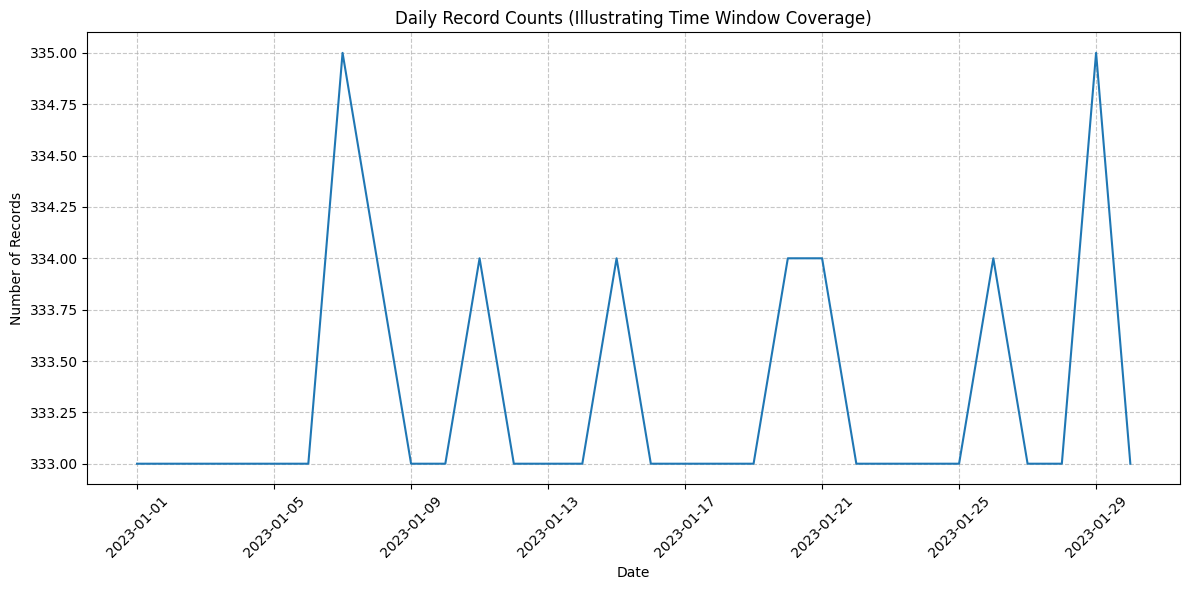

Observation: The plot shows a relatively uniform distribution of records per day, consistent with synthetic data generation. In real-world data, this might reveal sparsity, missing days, or significant fluctuations.

Distribution of 'device' in the dataset:


,proportion
device,
mobile,0.5936
desktop,0.3028
tablet,0.1036


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize daily record counts to check for uniform distribution over time
daily_counts = df['date'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_counts.index, y=daily_counts.values)
plt.title('Daily Record Counts (Illustrating Time Window Coverage)')
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Observation: The plot shows a relatively uniform distribution of records per day, consistent with synthetic data generation. In real-world data, this might reveal sparsity, missing days, or significant fluctuations.")

# Example of potential unbalanced history (if it were real data, we'd check value counts)
print("\nDistribution of 'device' in the dataset:")
display(df['device'].value_counts(normalize=True))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.